# Quantum Machine Learning for Air Pollution Forecasting

In [3]:
import os
import numpy as np
import tensorflow as tf
import pennylane as qml
import pandas as pd
from scipy import stats
from matplotlib import pyplot as plt

from LoadM import _LoadQModel
QPM = _LoadQModel('QKerasLayer.bin', 'DynexQML')
from DynexQML import PennylaneBridge, QKerasLayer, QuantumCallback

from utils.statistics import quantitative_analysis, get_mean_left_right_error_interval, verify_distribution_wilcoxtest

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import LeakyReLU

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

tf.keras.backend.set_floatx('float32')
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

In [4]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
  # Restrict access of TensorFlow to specific GPU
  try:
    tf.config.experimental.set_visible_devices(gpus[0], 'GPU')
  except RuntimeError as e:
    # Visible devices must be set at program startup
    print(e)

In [5]:
tf.config.experimental.get_visible_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'),
 PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [6]:
import dynex
dynex.__version__
dynex.test()

[DYNEX] TEST: dimod BQM construction...
*** precision: 0.0001 ***
[DYNEX] PASSED
[DYNEX] TEST: Dynex Sampler object...
[DYNEX] PASSED
[DYNEX] TEST: submitting sample file...
[DYNEX] PASSED
[DYNEX] TEST: retrieving samples...
[DYNEX] PASSED
[DYNEX] TEST RESULT: ALL TESTS PASSED


## Plot Functions

In [7]:
def plot_history(n_layers, history, ansatz, lookback, batch_size):
    plt.figure(figsize=(14,5), dpi=320, facecolor='w', edgecolor='k')
    plt.title(f"Quantum Model - {ansatz} - Loss for depth {n_layers} - Lookback {lookback}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.plot(history.history['loss'], label="Loss/Epoch")
    plt.plot(history.history['val_loss'], label="Val Loss/Epoch")
    plt.xticks(range(0, len(history.history['loss'])+1, 30))
    plt.legend()
    plt.grid()

    subdir = f"Val-False-Ansatz-{ansatz}-Lookback-{lookback}"
    
    path = os.path.abspath(os.path.join(os.getcwd(), 'plots', subdir))
    os.makedirs(path, exist_ok=True)
    filename = f"loss-history-pollution-{ansatz}-{n_layers}-layers-lookback-{lookback}-batch-{batch_size}.png"
    print(f"Saving history in {os.path.join(path,filename)}")
    plt.savefig(os.path.join(path,filename))

    plt.show()

    values = np.array([list(range(1, len(history.history['loss'])+1)), history.history['loss'], history.history['val_loss']])
    loss_pd = pd.DataFrame(np.transpose(values))
    loss_pd.columns = ["Epoch", "Loss", "Val Loss"]
    loss_pd = loss_pd.set_index("Epoch")
    path = os.path.abspath(os.path.join(os.getcwd(), 'analysis', subdir))
    os.makedirs(path, exist_ok=True)
    filename = f"loss-pollution-{ansatz}-{n_layers}-layers-lookback-{lookback}-batch-{batch_size}.csv"
    loss_pd.to_csv(os.path.join(path,filename))

In [8]:
def plot_prediction_versus_observed(n_layers, y_test, y_pred, mean_error_normal, ansatz, lookback, batch_size, prev):
    
    subdir = f"Val-False-Ansatz-{ansatz}-Lookback-{lookback}"
    
    for i in range(len(prev)):
        fig, ax = plt.subplots(figsize=(20,5), dpi=320, facecolor='w', edgecolor='k')
        plt.title(f"Quantum Model - {ansatz} - Lookback {lookback} - PM25 quantity for {prev[i]} hours ahead")
        plt.xlabel("Time")
        plt.ylabel("PM 2.5 (g/m³)")
        
        plt.plot(y_pred[:,i], label="Prediction", color='blue')
        plt.fill_between(range(y_pred.shape[0]), y_pred[:,i]-mean_error_normal[0,i], y_pred[:,i]+mean_error_normal[0,i], color='blue', alpha=0.05)
        plt.plot(y_test[:,i], label="Original", color='orange')
        plt.xticks(rotation=45)
        
        plt.legend()

        path = os.path.abspath(os.path.join(os.getcwd(), 'plots', subdir))
        filename = f"prediction-pollution-{ansatz}-{n_layers}-layers-lookback-{lookback}-batch-{batch_size}-{prev[i]}-hours.png"
        print(f"Saving Prediction Plot in {os.path.join(path,filename)}")
        os.makedirs(path, exist_ok=True)
        plt.savefig(os.path.join(path,filename))

        plt.show()

## Data loading

We used the data provided by the iSCAPE (Improving the Smart Control of Air Pollution in Europe) project (available at https://www.iscapeproject.eu/iscape-data, accessed on 08 January 2024). The three datasets used were:

- Living Lab Station data Jun-Oct 2019, Sutherland Memorial Park, Guildford (DS_TS_099)
- Field campaign data for evaluating green infrastructure in Guildford (DS_TS_102)
- Living Lab Station data Feb-Sept 2019, Stoke Park, Guildford (DS_TS_103).

In [9]:
def load_table(path, prev, lookback):
    X = pd.read_csv(path)
    X.dropna(axis=0,how='any',inplace=True)
    
    # We remove all outliers from dataset
    X = X[X['EXT_PM_25'] < 1000] 

    if lookback > 1:
        for col in X.columns:
            X[col+'_Lookback'] = X.loc[:,col].shift(lookback-1)
        X = X.iloc[lookback-1:, :]

    # We copy the values in X to prepare the y dataset. The first row is removed from y 
    # since it does not have a previous value to serve as forecast
    y = X[:].drop(X.index[0])
    
    # We remove the last line in X since it doesn't have an equivalent y
    X = X.iloc[:-prev[-1],:]
    
    # We create the final y dataset by creating a new column with the predictions and 
    # removing the unnecessary information
    for i in prev:
        y[f'Prev {i} hour'] = y.loc[:,"EXT_PM_25"].shift(-(i-1))
    
    if prev[-1] == 1:
        y= y.iloc[:, -1:]
    else:
        y= y.iloc[:-(prev[-1]-1), -len(prev):]

    return X, y.values

In [10]:
prevision_window = [1,2,3,4,5,6]
lookback = 1
batch_size = 128
#ansatz = "Wavelets"
ansatz = "QNN"

In [11]:
print("\nLoading Datasets\n")
path_stoke = os.path.abspath(os.path.join(os.getcwd(), 'data', 'stoke'))
path_suther = os.path.abspath(os.path.join(os.getcwd(), 'data', 'suther'))

filename_train = "wavelets-lvl5-train.csv" if ansatz == "Wavelets" else "train.csv"
filename_test  = "wavelets-lvl5-test.csv"  if ansatz == "Wavelets" else "test.csv"

train_file_stoke  = os.path.join(path_stoke, filename_train)
train_file_suther = os.path.join(path_suther, filename_train)
test_file_stoke   = os.path.join(path_stoke, filename_test)
test_file_suther  = os.path.join(path_suther, filename_test)

print(f"importing data from {train_file_stoke}")
X_train_stoke, y_train_stoke = load_table(train_file_stoke, prevision_window, lookback)
print(f"importing data from {train_file_suther}")
X_train_suther, y_train_suther = load_table(train_file_suther, prevision_window, lookback)

X_all = pd.concat([X_train_stoke, X_train_suther], axis=0)
y_all = np.vstack((y_train_stoke,y_train_suther))

#X_all = X_train_stoke
#y_all = y_train_stoke


print(f"importing data from {test_file_stoke}")
X_test_stoke, y_test_stoke = load_table(test_file_stoke, prevision_window, lookback)
print(f"importing data from {test_file_suther}")
X_test_suther, y_test_suther = load_table(test_file_suther, prevision_window, lookback)

X_test = pd.concat([X_test_stoke, X_test_suther], axis=0)
y_test = np.vstack((y_test_stoke,y_test_suther))

#X_test = X_test_stoke
#y_test = y_test_stoke


plot_time = X_test['Time'].values


Loading Datasets

importing data from /home/otto.pires/dynex-poc/data/stoke/train.csv
importing data from /home/otto.pires/dynex-poc/data/suther/train.csv
importing data from /home/otto.pires/dynex-poc/data/stoke/test.csv
importing data from /home/otto.pires/dynex-poc/data/suther/test.csv


In [12]:
if lookback > 1:
    X_all = X_all.drop(["Time", "Month", "Time_Lookback", "Month_Lookback"], axis=1)
    X_test = X_test.drop(["Time", "Month", "Time_Lookback", "Month_Lookback"], axis=1)
else:
    X_all = X_all.drop(["Time", "Month"], axis=1)
    X_test = X_test.drop(["Time", "Month"], axis=1)

In [13]:
print(f"\nThere are {X_all.shape[1]} features and {X_all.shape[0]} instances in All Train set\n")
print(X_all.head())
print(f"\nThere are {X_test.shape[1]} features and {X_test.shape[0]} instances in All Test set\n")
print(X_test.head())


There are 16 features and 4352 instances in All Train set

        TEMP        HUM       PRESS  EXT_PM_25    CO_PRE    NO2_PRE  \
0  14.305167  46.894333  101.311333  12.333333  0.235167  14.397885   
1  13.923167  46.929833  101.320000  15.016667  0.226035  16.237973   
2  13.794167  47.107667  101.349667  17.533333  0.219977  16.949071   
3  13.798500  47.212667  101.387333  18.966667  0.218026  16.976633   
4  13.862167  47.418500  101.429167  13.700000  0.215322  16.410233   

      O3_PRE  SIN HOUR  COS HOUR   SIN DAY  COS DAY  SIN MONTH     COS MONTH  \
0  21.885943  0.000000  1.000000  0.201299  0.97953        1.0  6.123234e-17   
1  18.874601  0.258819  0.965926  0.201299  0.97953        1.0  6.123234e-17   
2  18.829282  0.500000  0.866025  0.201299  0.97953        1.0  6.123234e-17   
3  19.074056  0.707107  0.707107  0.201299  0.97953        1.0  6.123234e-17   
4  19.427294  0.866025  0.500000  0.201299  0.97953        1.0  6.123234e-17   

         LAT      LONG  ALT  
0 

In [14]:
print("Size y_all", len(y_all),"\n", y_all[:5])
print("Size y_test_all", len(y_test),"\n", y_test[:5])
print("\n#########\n")

Size y_all 4352 
 [[15.01666667 17.53333333 18.96666667 13.7        17.33333333 26.81666667]
 [17.53333333 18.96666667 13.7        17.33333333 26.81666667 31.11666667]
 [18.96666667 13.7        17.33333333 26.81666667 31.11666667 31.        ]
 [13.7        17.33333333 26.81666667 31.11666667 31.         31.4       ]
 [17.33333333 26.81666667 31.11666667 31.         31.4        29.36666667]]
Size y_test_all 1476 
 [[2.98333333 3.85       4.35       4.51666667 4.75       3.81666667]
 [3.85       4.35       4.51666667 4.75       3.81666667 3.35      ]
 [4.35       4.51666667 4.75       3.81666667 3.35       3.45      ]
 [4.51666667 4.75       3.81666667 3.35       3.45       2.41666667]
 [4.75       3.81666667 3.35       3.45       2.41666667 1.83333333]]

#########



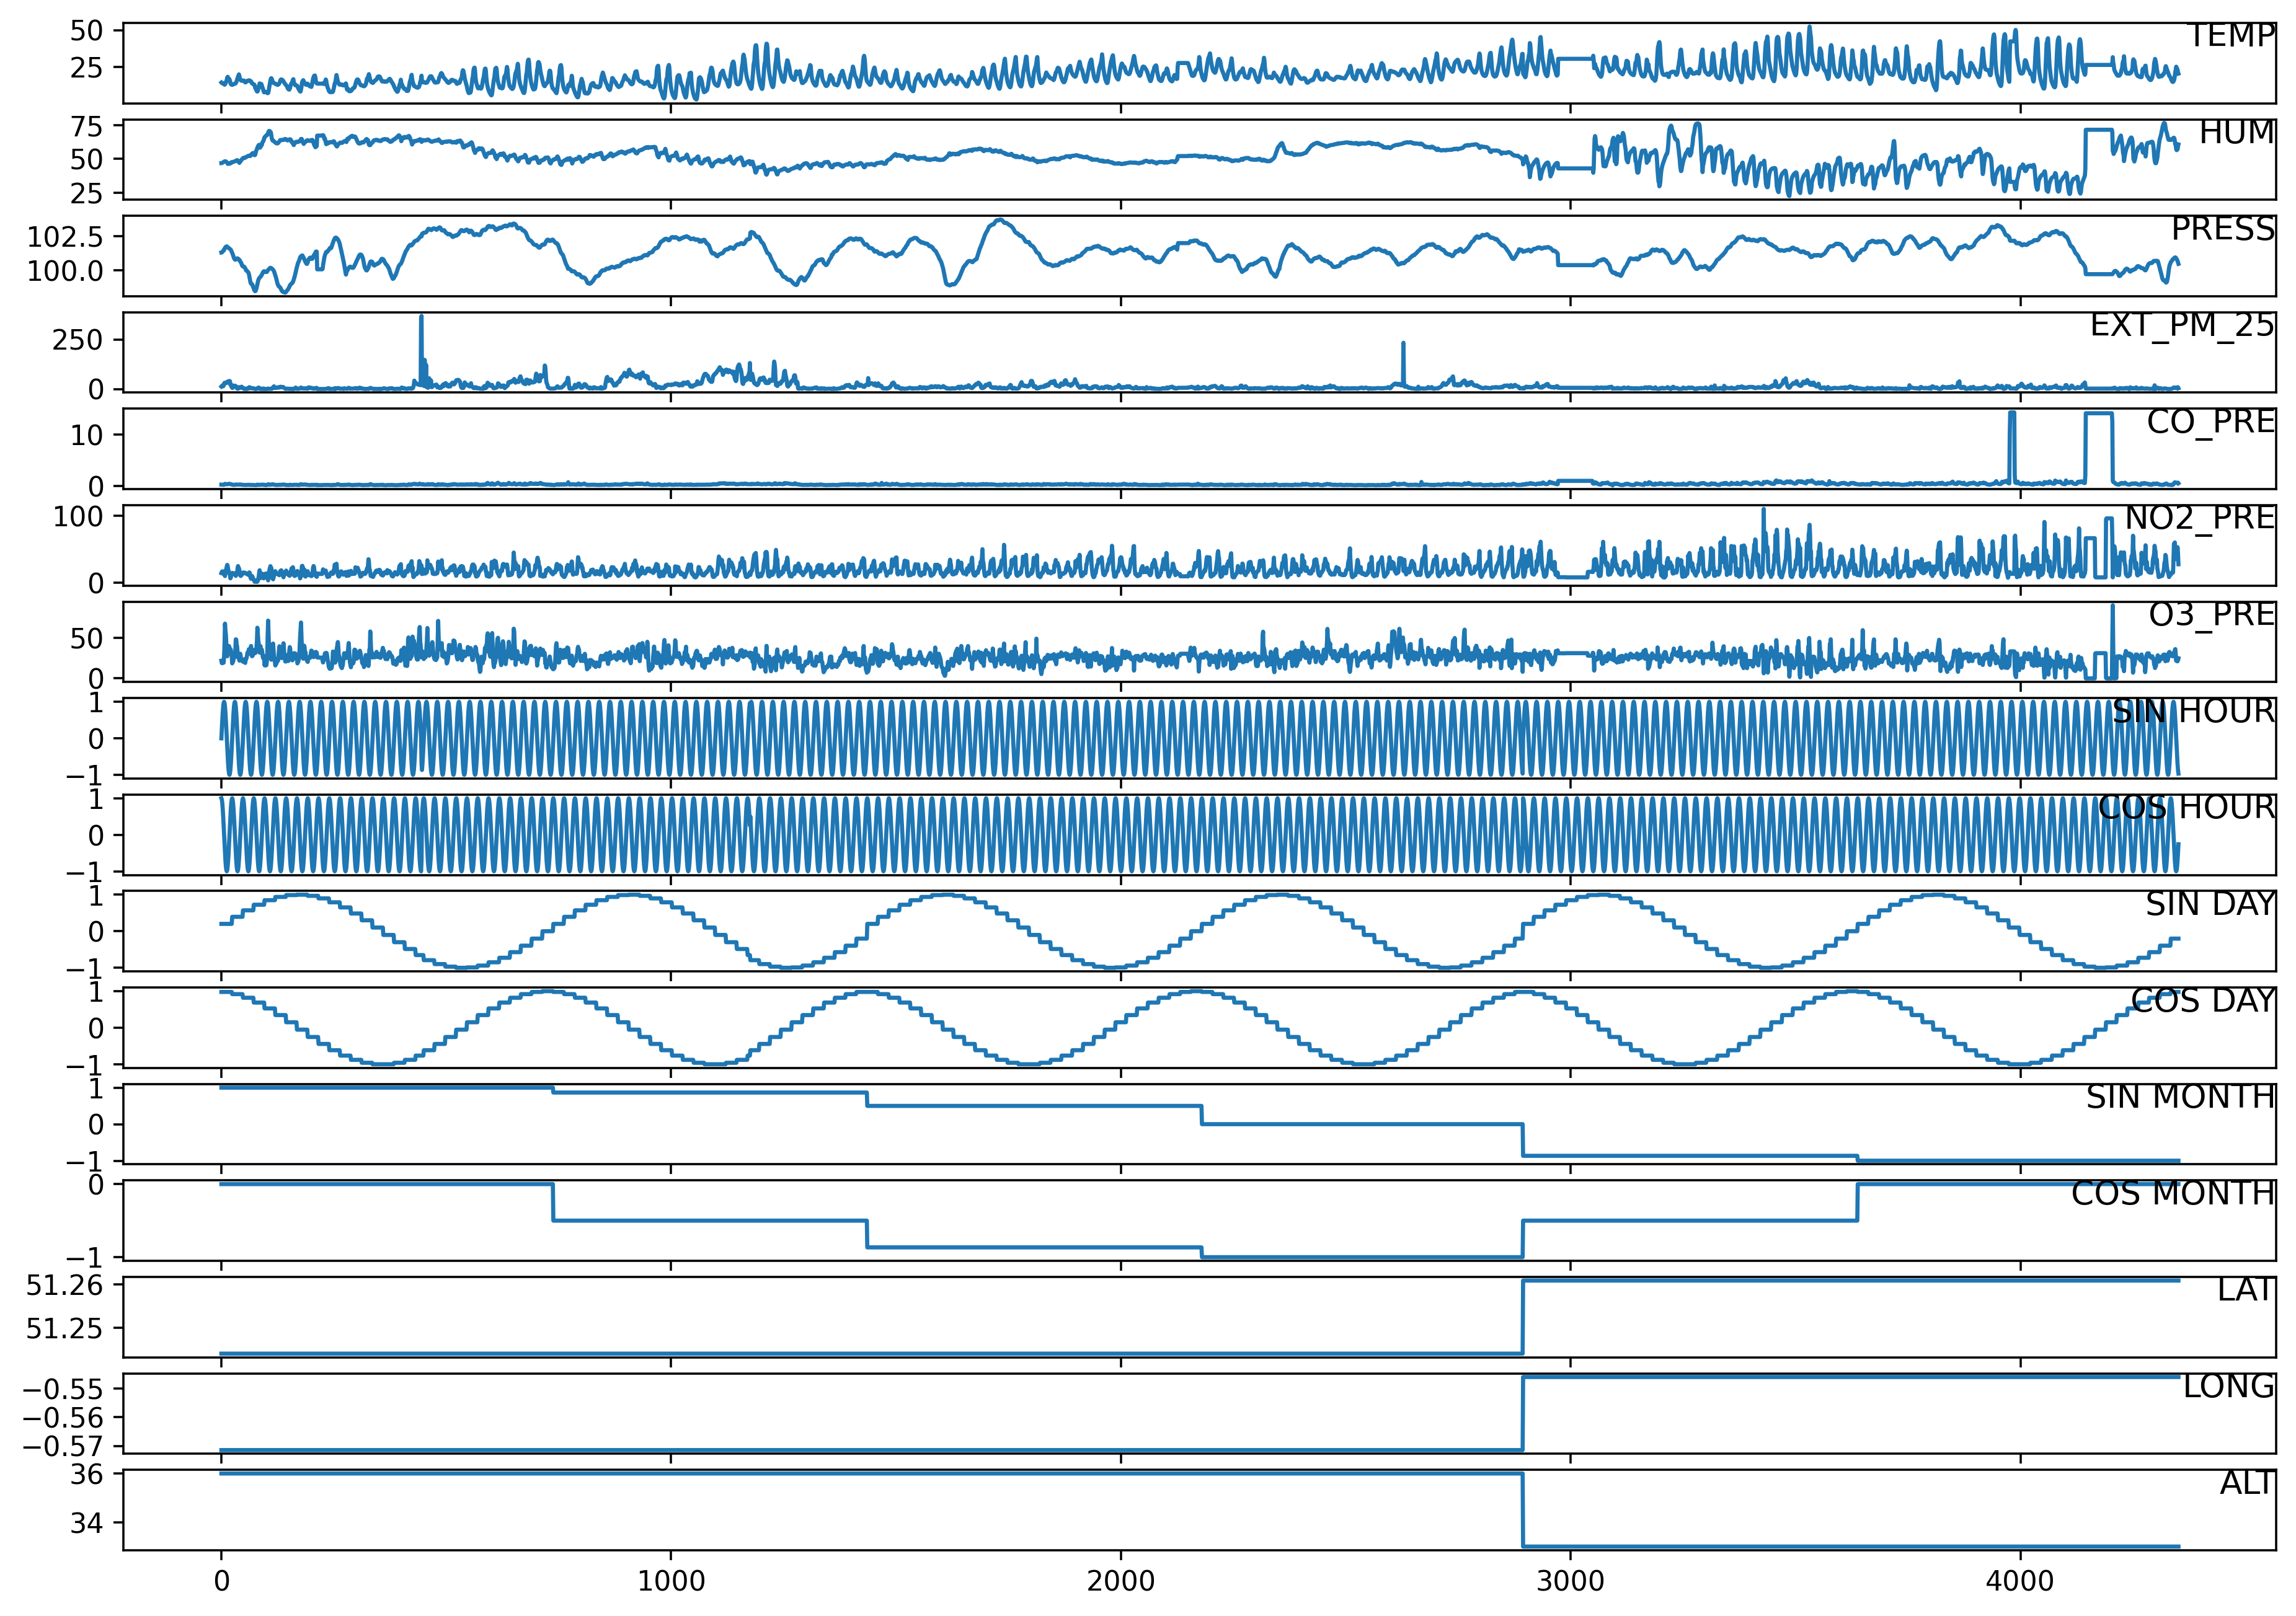

In [15]:
# load dataset
values = X_all.values
# specify columns to plot
groups = [i for i in range(len(X_all.columns))]
i = 1
# plot each column
plt.figure(figsize=(14,10), dpi=320, facecolor='w', edgecolor='k')
for group in groups:
    plt.subplot(len(groups), 1, i)
    plt.plot(values[:, group])
    plt.title(X_all.columns[group], y=0.5, loc='right')
    i += 1
plt.show()

In [16]:
X_all.max()

TEMP         5.249100e+01
HUM          7.654417e+01
PRESS        1.037557e+02
EXT_PM_25    3.686667e+02
CO_PRE       1.439311e+01
NO2_PRE      1.101329e+02
O3_PRE       9.032694e+01
SIN HOUR     1.000000e+00
COS HOUR     1.000000e+00
SIN DAY      9.987165e-01
COS DAY      1.000000e+00
SIN MONTH    1.000000e+00
COS MONTH    6.123234e-17
LAT          5.126085e+01
LONG        -5.460530e-01
ALT          3.600000e+01
dtype: float64

## Data Preprocessing

### Data Scaling

The feature map reads the data as a rotation on angle $\theta$, therefore we will scale our data on the range 0 to $2\pi$.

In [17]:
print("\nScaling Data\n")
scaler_x = MinMaxScaler(feature_range=(0, 1))
Xs_all  = scaler_x.fit_transform(X_all)
Xs_test = scaler_x.transform(X_test)


Scaling Data



In [18]:
print(Xs_all[0:5])

[[0.2333881  0.45133035 0.54737362 0.03345389 0.01115034 0.12087407
  0.24229695 0.5        1.         0.60077861 0.98973865 1.
  1.         0.         0.         1.        ]
 [0.22571913 0.45198728 0.54897846 0.04073237 0.01051252 0.13777143
  0.2089587  0.62940952 0.98296291 0.60077861 0.98973865 1.
  1.         0.         0.         1.        ]
 [0.22312935 0.45527808 0.55447195 0.04755877 0.01008943 0.14430137
  0.20845699 0.75       0.9330127  0.60077861 0.98973865 1.
  1.         0.         0.         1.        ]
 [0.22321635 0.45722111 0.56144682 0.05144665 0.00995316 0.14455447
  0.21116685 0.85355339 0.85355339 0.60077861 0.98973865 1.
  1.         0.         0.         1.        ]
 [0.22449451 0.46103005 0.56919326 0.03716094 0.0097643  0.13935328
  0.21507751 0.9330127  0.75       0.60077861 0.98973865 1.
  1.         0.         0.         1.        ]]


In [19]:
print(Xs_test[0:5])

[[0.37895452 0.51484871 0.5996852  0.00750452 0.00675747 0.10170549
  0.27091289 0.5        1.         0.60077861 0.98973865 0.25
  0.1339746  0.         0.         1.        ]
 [0.36083944 0.51485796 0.59755571 0.00809222 0.00508039 0.09910561
  0.27682374 0.62940952 0.98296291 0.60077861 0.98973865 0.25
  0.1339746  0.         0.         1.        ]
 [0.34631458 0.51520955 0.59737053 0.01044304 0.0046873  0.09526089
  0.28257034 0.75       0.9330127  0.60077861 0.98973865 0.25
  0.1339746  0.         0.         1.        ]
 [0.33038442 0.5148703  0.59712363 0.01179928 0.00441445 0.09168426
  0.28150109 0.85355339 0.85355339 0.60077861 0.98973865 0.25
  0.1339746  0.         0.         1.        ]
 [0.31906835 0.51708781 0.59767916 0.01225136 0.00421601 0.10371552
  0.28205224 0.9330127  0.75       0.60077861 0.98973865 0.25
  0.1339746  0.         0.         1.        ]]


### Spliting Train and Validation sets

In [20]:
print("\nSplitting Train Data\n")
train_ratio = 0.7
Xs_train, Xs_val, y_train, y_val = train_test_split(Xs_all, y_all, test_size=1 - train_ratio)


Splitting Train Data



In [21]:
print(f"There are {Xs_train.shape[1]} features and {Xs_train.shape[0]} instances in Train set")
print(f"There are {Xs_val.shape[1]} features and {Xs_val.shape[0]} instances in Val set")
print(f"There are {Xs_test.shape[1]} features and {Xs_test.shape[0]} instances in Test set")

There are 16 features and 3046 instances in Train set
There are 16 features and 1306 instances in Val set
There are 16 features and 1476 instances in Test set


## Quantum Layer

In [22]:
n_qubits = Xs_train.shape[1] # n_features
print(f"\nCircuit size: {n_qubits} qubits\n")


Circuit size: 16 qubits



In [23]:
n_layers = 1
weight_shapes = {"weights": (n_layers, n_qubits, 3)}

In [24]:
weight_shapes

{'weights': (1, 16, 3)}

In [25]:
def AngleFeatureMap(inputs):
    nqubits = len(inputs)
    for idx in range(nqubits):
        qml.Hadamard(wires=idx)
    qml.templates.AngleEmbedding(inputs,rotation='Y', wires=range(nqubits))

In [28]:
def strong_entangling(params):
    nqubits = 16
    inputs = params[:nqubits]
    weights = np.reshape(params[nqubits:], (-1, nqubits, 3))
    #nqubits = len(inputs)
    AngleFeatureMap(inputs)
    qml.StronglyEntanglingLayers(weights=weights, wires=range(nqubits), ranges=[1 for _ in range(len(weights))])
    return [qml.expval(qml.PauliZ(wires=i)) for i in range(nqubits)]

In [29]:
def draw_circuit(qnn, n_qubits, weights):
    sampl_input = np.random.uniform(low=0, high=2*np.pi, size=(n_qubits))
    sampl_weights = np.random.uniform(low=0, high=np.pi, size=weights['weights'])
    params = np.concatenate((sampl_input, sampl_weights.flatten()))
    _ = qml.draw_mpl(strong_entangling, style="black_white")(params)

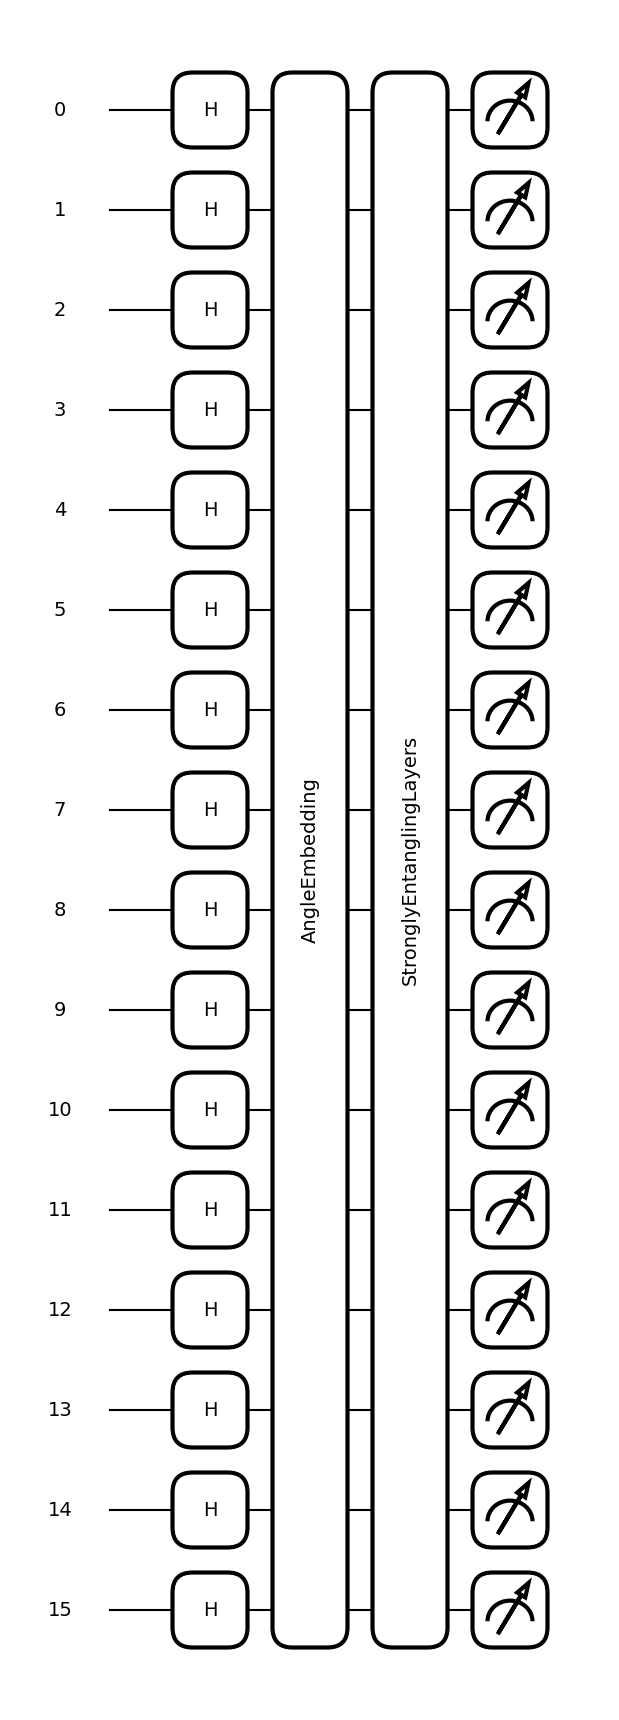

In [30]:
draw_circuit(strong_entangling, n_qubits, weight_shapes)

## Quantum Neural Network

In [31]:
def create_quantum_model(n_qubits, weights, prev):
    input_layer = tf.keras.layers.Input(shape=(n_qubits,))
    
    sampl_input = np.random.uniform(low=0, high=2*np.pi, size=(n_qubits))
    sampl_weights = np.random.uniform(low=0, high=np.pi, size=weights['weights'])
    params = np.concatenate((sampl_input, sampl_weights.flatten()))
    bridge = PennylaneBridge(circuit=strong_entangling, params=params, wires=n_qubits, draw=True)
    q_layer = QKerasLayer(
        quantumBridge=bridge, 
        weightShapes=weights, 
        outputDim=n_qubits,
        mainnet=True,
        numReads=1,
        annealingTime=10000,
        useBatchOptimization=True)


    activation=tf.keras.layers.Activation(tf.keras.activations.relu)
    output_layer = tf.keras.layers.Dense(len(prev), LeakyReLU(alpha=0.01))

    model = tf.keras.models.Sequential([
        input_layer
        , q_layer
        , activation
        , output_layer])
    
    opt = tf.keras.optimizers.Adam(learning_rate = 0.001)
    
    model.compile(loss=['mse'], optimizer=opt, metrics=['mae'])
    
    return model

In [32]:
model = create_quantum_model(n_qubits, weight_shapes, prevision_window)
input_shape = (n_qubits,)
model.build(input_shape)
model.summary()

Could not validate network time - no servers responded
-----------/ Visualize Circuit /-----------
 0: ──H─╭AngleEmbedding(M0)─╭StronglyEntanglingLayers(M1)─┤  <Z>
 1: ──H─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
 2: ──H─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
 3: ──H─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
 4: ──H─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
 5: ──H─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
 6: ──H─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
 7: ──H─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
 8: ──H─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
 9: ──H─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
10: ──H─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
11: ──H─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
12: ──H─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
13: ──H─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1

2025-09-04 09:52:01.221560: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-04 09:52:01.835724: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1616] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 26666 MB memory:  -> device: 0, name: Tesla V100S-PCIE-32GB, pci bus id: 0000:30:00.0, compute capability: 7.0


## Training

After the model is created we start the training

In [ ]:
es=EarlyStopping(monitor='val_loss', min_delta=0, patience=6, verbose=0, mode='auto', baseline=None, restore_best_weights=True)

subdir = f"Val-False-Ansatz-{ansatz}-Lookback-{lookback}"

checkpoint_path = os.path.join('checkpoint', subdir, f"cp-{ansatz}-lookback-{lookback}-depth-{n_layers}-"+"{epoch:04d}.ckpt")
os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)

# Create a callback that saves the model's weights
n_batches = len(Xs_train) / batch_size
n_batches = int(np.ceil(n_batches))
cp_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path
                                                    , save_weights_only=True
                                                    , verbose=0
                                                    , save_freq=n_batches)

history_model = model.fit(Xs_train, y_train
                       , epochs=100, batch_size=batch_size
                       , verbose=1
                       , validation_data=(Xs_val, y_val)
                       , callbacks = [cp_callback])

### Plotting Loss

In [ ]:
plot_history(n_layers, history_model, ansatz, lookback, batch_size)

## Prediction

Prediction intervals were estimated using quantile regression applied to the errors of predictions made in the test dataset. These intervals were computed for 1 hour ahead.

In [ ]:
y_pred = model.predict(Xs_test,verbose=0)
mean_predictions, mean_error_normal, mean_error_left_normal, mean_error_right_normal = get_mean_left_right_error_interval(model, Xs_val, y_val, y_test, y_pred)

In [ ]:
error_interval = [[str(i+1)+" hours"
                              , mean_predictions[0][i]
                              , mean_error_normal[0][i]
                              , mean_error_left_normal[0][i]
                              , mean_error_right_normal[0][i]
                          ] for i in range(len(mean_predictions[0]))
                         ]
pred_interval = pd.DataFrame(error_interval)
pred_interval.columns = ['Index', 'Mean Pred', 'Error Normal', 'Error Left', 'Error Right']
pred_interval = pred_interval.set_index('Index')
pred_interval.loc['Mean'] = pred_interval.mean()

pred_interval

In [ ]:
subdir = f"Val-False-Ansatz-{ansatz}-Lookback-{lookback}"
path = os.path.abspath(os.path.join(os.getcwd(), 'analysis', subdir))
os.makedirs(path, exist_ok=True)  
filename = f"pred_interval-{ansatz}-lookback-{lookback}-batch-{batch_size}-depth-{n_layers}.csv"
print(f"Saving Pred Interval in {os.path.join(path,filename)}")
pred_interval.to_csv(os.path.join(path,filename), index=False)

In [ ]:
plot_prediction_versus_observed(n_layers, y_test, y_pred, mean_error_normal, ansatz, lookback, batch_size, prevision_window)

## Statistical Analysis

The evaluation of our proposed Quantum Machine Learning (QML) method involved a comprehensive analysis of various performance metrics applied to both training and test datasets. These metrics included mean square error (MSE), mean absolute error (MAE), and normalized mean square error (NMSE), along with the Pearson correlation coefficient (r)

In [ ]:
all_analysis = quantitative_analysis(y_test, y_pred)
all_analysis

In [ ]:
subdir = f"Val-False-Ansatz-{ansatz}-Lookback-{lookback}"

path = os.path.abspath(os.path.join(os.getcwd(), 'analysis', subdir))
os.makedirs(path, exist_ok=True)  

filename = f"metrics-{ansatz}-lookback-{lookback}-batch-{batch_size}-depth-{n_layers}.csv"
print(f"Saving Metrics in {os.path.join(path, filename)}")

all_analysis.to_csv(os.path.join(path, filename))

print("\n#########\n")